# M6-B1 — Analyse de dérive (à compléter)

## 1. Exploration — distributions référence vs prod

Référence: 1500 lignes, 15 colonnes
Production: 3000 lignes, 16 colonnes
Colonnes de référence: ['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs', 'fico_range_low', 'revol_util', 'loan_status']
Colonnes de production: ['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs', 'fico_range_low', 'revol_util', 'loan_status', 'timestamp']

Variables numériques: ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'revol_util']
Variables catégorielles: ['term', 'grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose']

=== loan_amnt ===


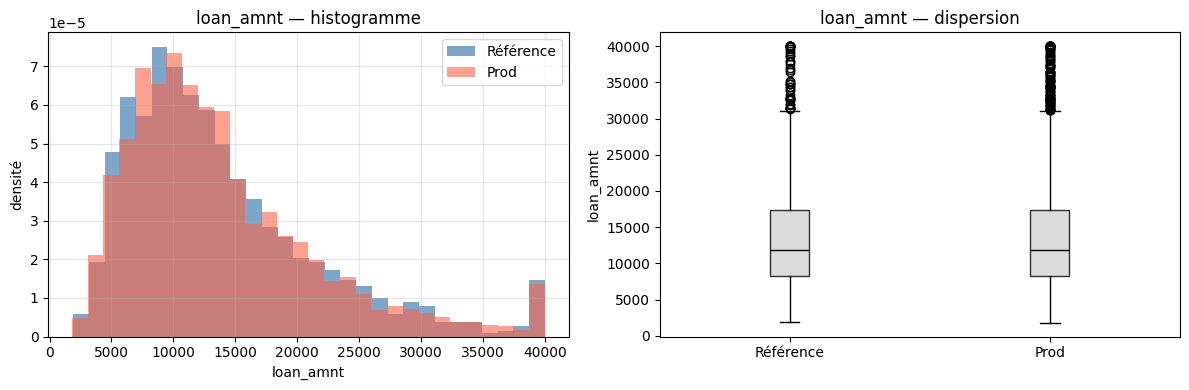


=== int_rate ===


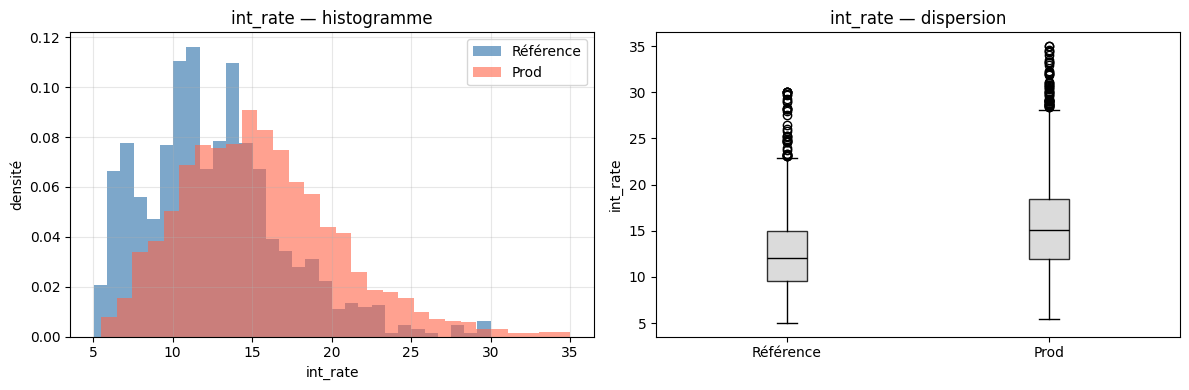


=== installment ===


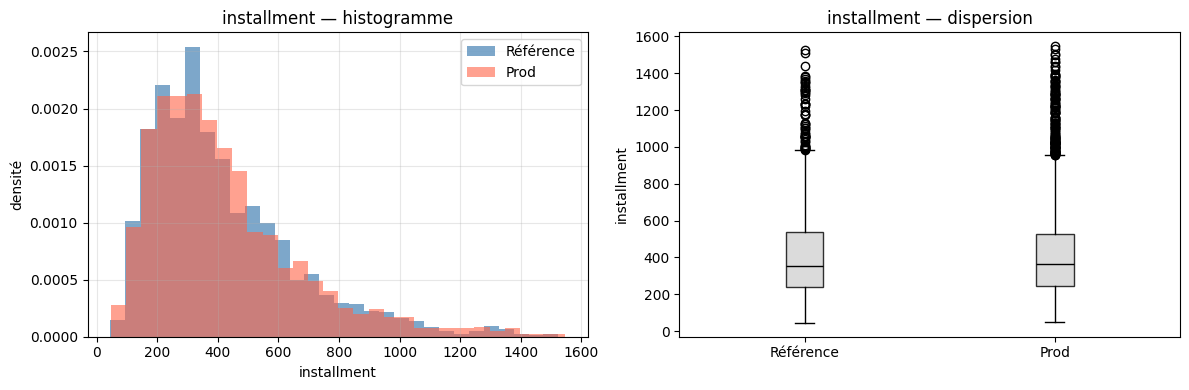


=== annual_inc ===


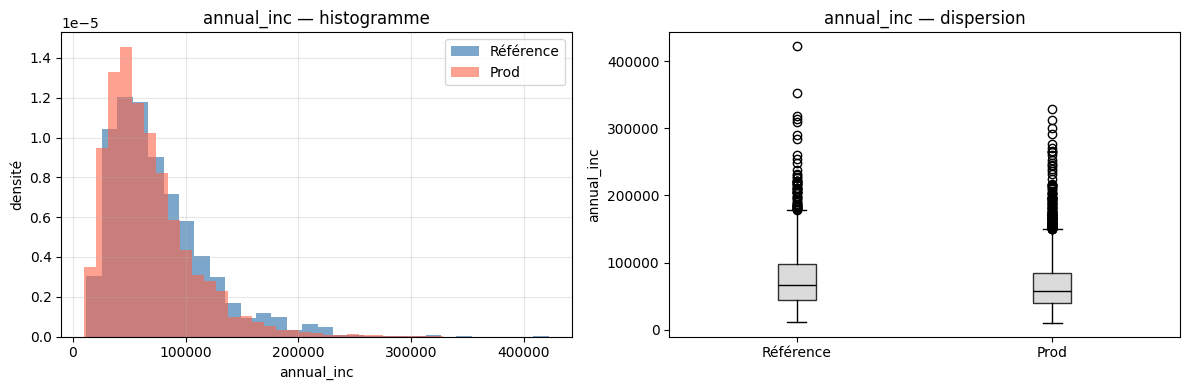


=== dti ===


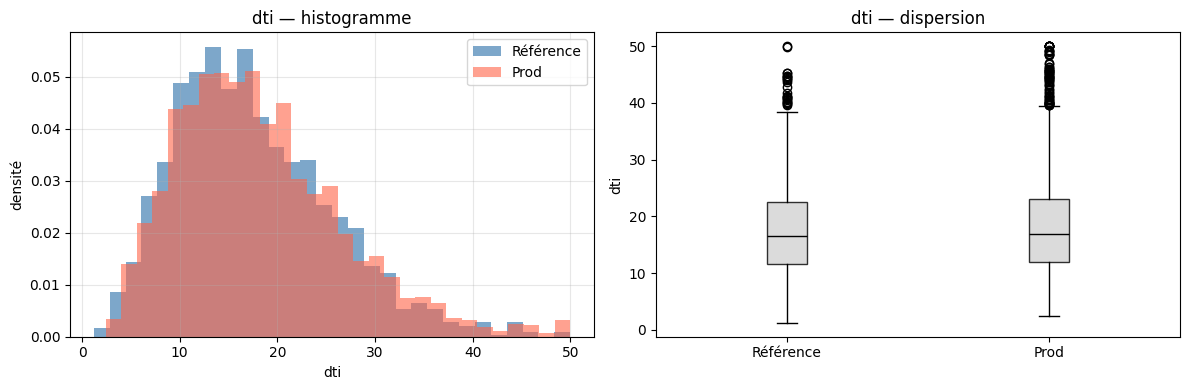


=== delinq_2yrs ===


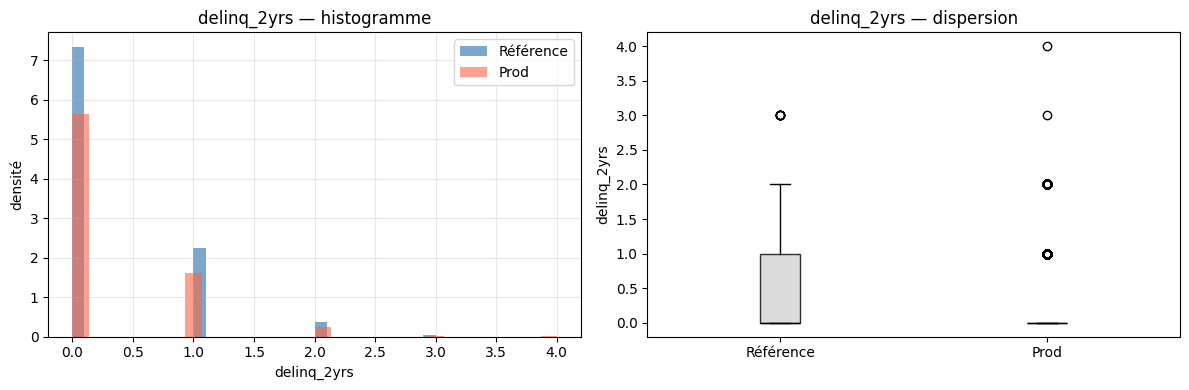


=== fico_range_low ===


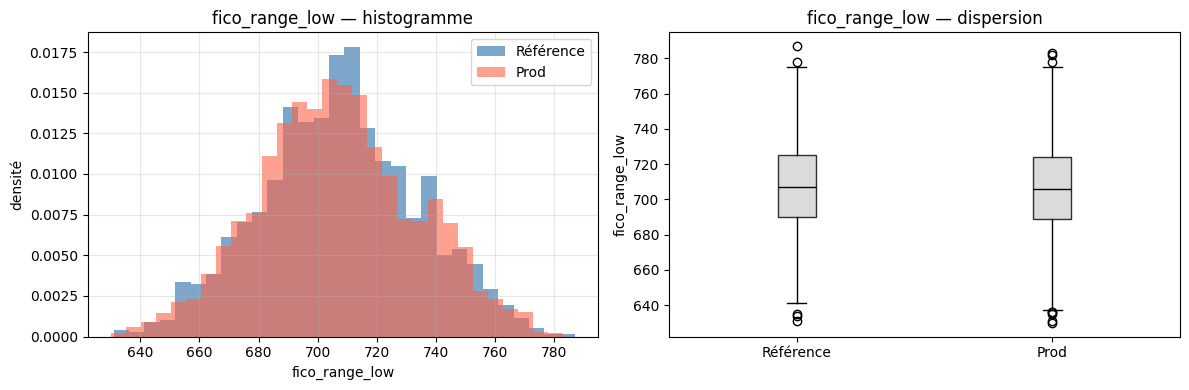


=== revol_util ===


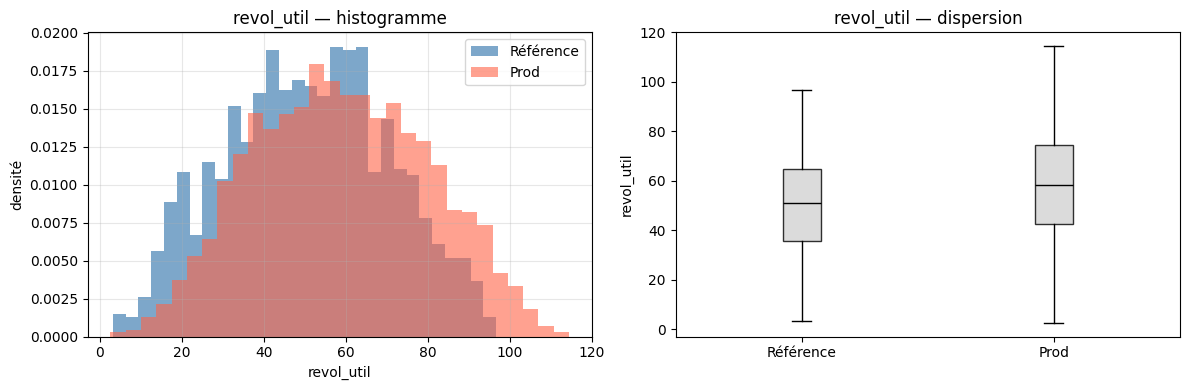


=== term ===


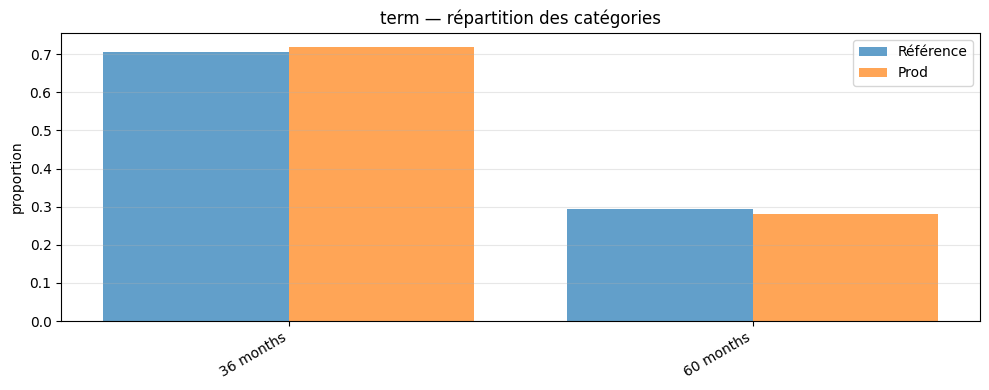


=== grade ===


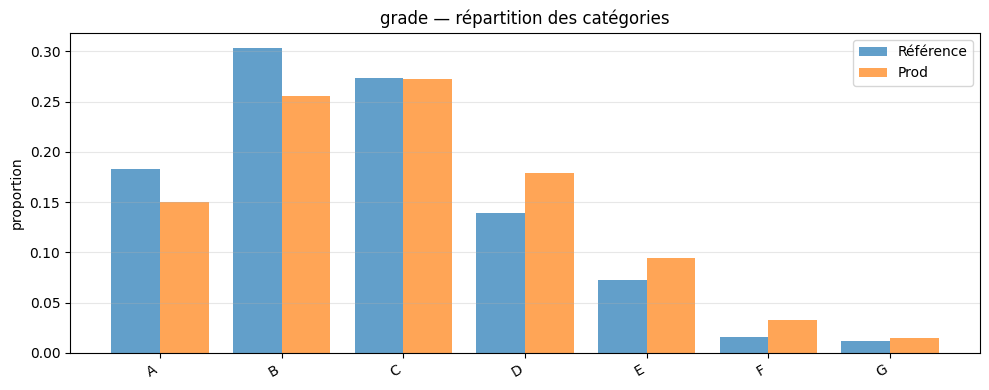


=== emp_length ===


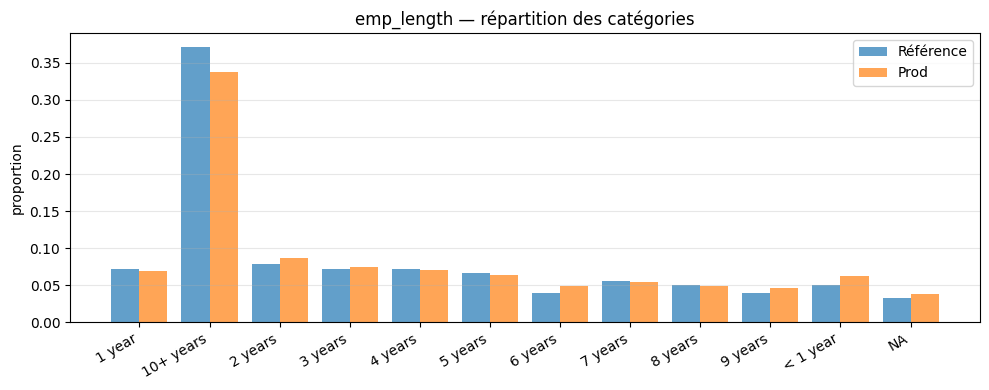


=== home_ownership ===


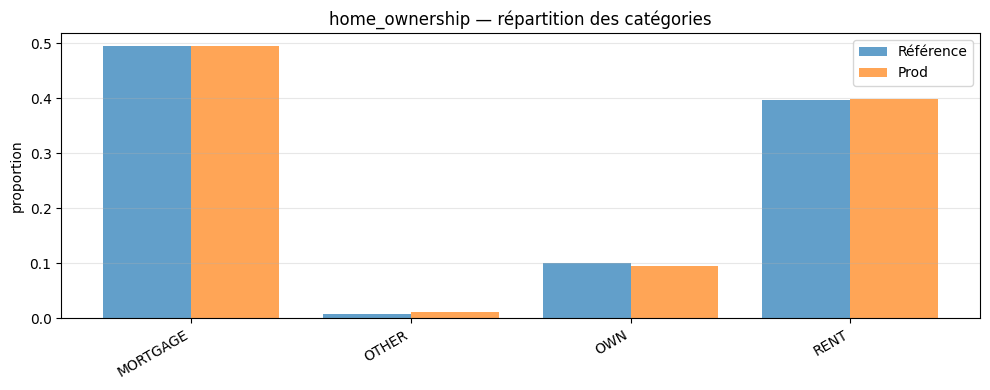


=== verification_status ===


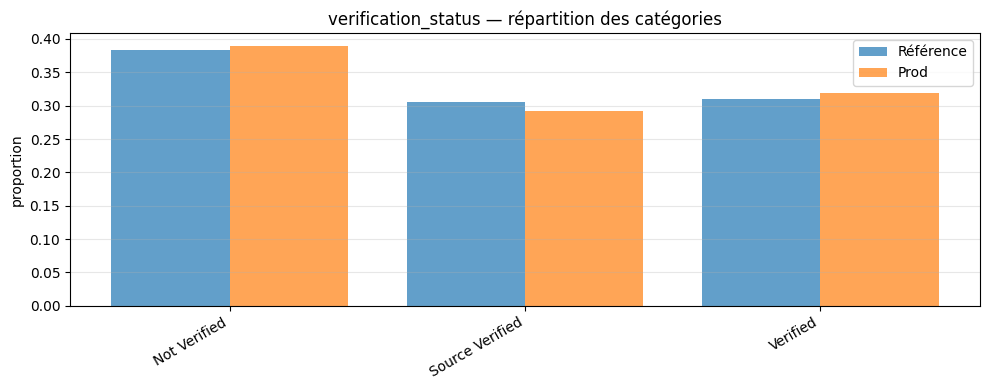


=== purpose ===


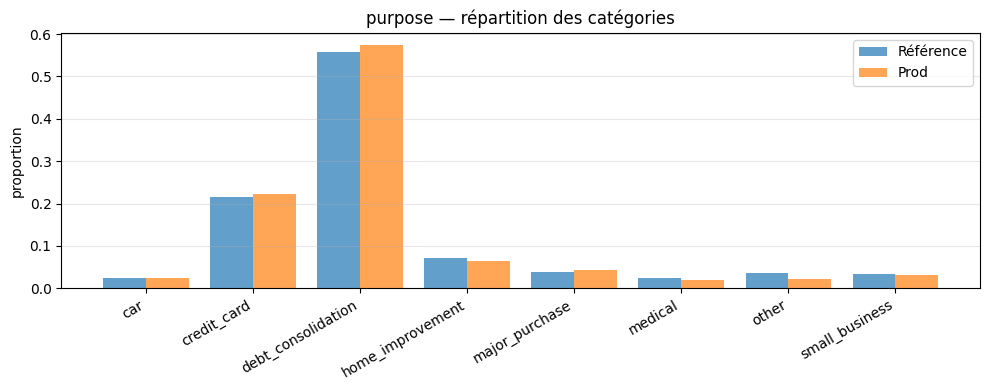

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

ref = pd.read_csv('../data/reference_set.csv')
prod = pd.read_csv('../data/prod_3months.csv')

print(f'Référence: {ref.shape[0]} lignes, {ref.shape[1]} colonnes')
print(f'Production: {prod.shape[0]} lignes, {prod.shape[1]} colonnes')
print('Colonnes de référence:', list(ref.columns))
print('Colonnes de production:', list(prod.columns))

# On compare les mêmes variables métier ; on exclut la cible et les colonnes de temps
feature_cols = [c for c in ref.columns if c not in ['loan_status', 'timestamp']]

# Détection automatique des types pour les graphiques
numeric_cols = []
categorical_cols = []
for col in feature_cols:
    ref_dtype = pd.api.types.is_numeric_dtype(ref[col])
    prod_dtype = pd.api.types.is_numeric_dtype(prod[col])
    if ref_dtype and prod_dtype:
        numeric_cols.append(col)
    else:
        categorical_cols.append(col)

print(f'\nVariables numériques: {numeric_cols}')
print(f'Variables catégorielles: {categorical_cols}')


def plot_numeric_distribution(df_ref, df_prod, col, bins=30):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ref_values = df_ref[col].dropna()
    prod_values = df_prod[col].dropna()

    xmin = min(ref_values.min(), prod_values.min())
    xmax = max(ref_values.max(), prod_values.max())
    if pd.isna(xmin) or pd.isna(xmax):
        return

    axes[0].hist(ref_values, bins=bins, alpha=0.7, density=True, color='steelblue', label='Référence')
    axes[0].hist(prod_values, bins=bins, alpha=0.6, density=True, color='tomato', label='Prod')
    axes[0].set_title(f'{col} — histogramme')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('densité')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].boxplot([ref_values, prod_values], tick_labels=['Référence', 'Prod'], patch_artist=True,
                    boxprops={'facecolor': 'lightgray', 'alpha': 0.8},
                    medianprops={'color': 'black'})
    axes[1].set_title(f'{col} — dispersion')
    axes[1].set_ylabel(col)
    fig.tight_layout()
    plt.show()


def plot_categorical_distribution(df_ref, df_prod, col):
    ref_counts = df_ref[col].fillna('NA').value_counts(normalize=True)
    prod_counts = df_prod[col].fillna('NA').value_counts(normalize=True)
    labels = sorted(set(ref_counts.index).union(prod_counts.index), key=lambda x: str(x))
    ref_vals = [ref_counts.get(l, 0) for l in labels]
    prod_vals = [prod_counts.get(l, 0) for l in labels]

    x = range(len(labels))
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar([i - 0.2 for i in x], ref_vals, width=0.4, alpha=0.7, label='Référence')
    ax.bar([i + 0.2 for i in x], prod_vals, width=0.4, alpha=0.7, label='Prod')
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.set_title(f'{col} — répartition des catégories')
    ax.set_ylabel('proportion')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    plt.show()


# Exploration visuelle feature par feature
for col in numeric_cols:
    print(f'\n=== {col} ===')
    plot_numeric_distribution(ref, prod, col)

for col in categorical_cols:
    print(f'\n=== {col} ===')
    plot_categorical_distribution(ref, prod, col)



### Synthèse visuelle

- `int_rate` : augmentation nette du niveau, médiane de 12.0 à 15.1 et p90 de 18.6 à 21.9 ; la production est clairement plus chère.
- `revol_util` : hausse du niveau d’usage du crédit, médiane de 50.5 à 58.1 et p90 de 76.7 à 87.3 ; la demande est plus intensive.
- `grade` : migration visible vers les grades B/C/D/E ; la part des dossiers A diminue et les profils plus risqués deviennent plus fréquents.

Conclusion : on observe une dérive claire des distributions de production, surtout sur le niveau de risque et la qualité des dossiers.

## 2. Détection statistique — PSI · KS · Chi²

Le signal observé est avant tout compatible avec un data drift, et non avec un concept drift avéré. Les distributions des variables clés se déplacent nettement entre la référence et la production : `int_rate` augmente, `revol_util` monte et la distribution de `grade` se déplace vers des profils plus risqués. Ces changements sont cohérents avec une évolution de la population de clients et du niveau de risque moyen, ce que les métriques PSI / KS / Chi² viennent confirmer.

Selon le mini-cours, un data drift est un changement de distribution des features sans que la logique métier de la relation X → Y ait nécessairement changé. Ici, le point décisif est que la performance de tri reste stable : sur les logs de scoring, l'AUC est quasi identique entre les périodes initiale et tardive (environ 0.742 vs 0.746). Un AUC stable suggère que le modèle continue à ordonner correctement les dossiers, même si les profils entrants ont changé. Cela ne prouve pas l'absence totale de concept drift, mais il n'y a pas ici de signal fort de rupture de la relation entrée-cible.

On conclut donc à un data drift plausible, avec un risque de calibration / shift de score à surveiller. Un concept drift serait plutôt suspecté si l'AUC baissait nettement, si la relation X → Y se modifiait réellement, ou si l'on observait un changement structurel de performance malgré des distributions de features stables. En pratique, le diagnostic retenu est donc : dérive des données, puis surveillance de la calibration et test de la performance dans le temps.


In [44]:
import sys
from pathlib import Path

import pandas as pd

# Forcer le rechargement du module pour éviter les imports stales du noyau Jupyter
sys.modules.pop('drift_detection', None)

# Ajout du dossier src au chemin pour importer le module de détection
project_root = Path.cwd().resolve().parent
sys.path.append(str(project_root / 'src'))

from drift_detection import (
    chi2_pvalue,
    drift_report,
    ks_pvalue,
    population_stability_index,
)

reference = pd.read_csv('../data/reference_set.csv')
production = pd.read_csv('../data/prod_3months.csv')

numeric_cols = [
    'loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
    'delinq_2yrs', 'fico_range_low', 'revol_util'
]
categorical_cols = [
    'term', 'grade', 'emp_length', 'home_ownership', 'verification_status',
    'purpose'
]

print('=== Détection statistique — appels des fonctions ===')

for col in numeric_cols:
    try:
        psi = population_stability_index(reference[col], production[col])
        pvalue_ks = ks_pvalue(reference[col], production[col])
        print(f'{col}: PSI={psi:.4f} | KS_pvalue={pvalue_ks:.4f}')
    except NotImplementedError:
        print(f'{col}: TODO dans src/drift_detection.py (fonction non implémentée)')
    except Exception as exc:
        print(f'{col}: erreur d’exécution -> {exc}')

for col in categorical_cols:
    try:
        pvalue_chi2 = chi2_pvalue(reference[col], production[col])
        print(f'{col}: Chi2_pvalue={pvalue_chi2:.4f}')
    except NotImplementedError:
        print(f'{col}: TODO dans src/drift_detection.py (fonction non implémentée)')
    except Exception as exc:
        print(f'{col}: erreur d’exécution -> {exc}')

try:
    report = drift_report(reference, production, numeric_cols, categorical_cols)
    if report is not None and 'psi' in report.columns:
        report = report.copy()
        report['psi'] = pd.to_numeric(report['psi'], errors='coerce')
        display(report.sort_values('psi', ascending=False).head(10))
    elif report is not None:
        display(report.head())
    else:
        print('drift_report: DataFrame vide')
except NotImplementedError:
    print('drift_report: TODO dans src/drift_detection.py (fonction non implémentée)')
except Exception as exc:
    print(f'drift_report: erreur d’exécution -> {exc}')

=== Détection statistique — appels des fonctions ===
loan_amnt: PSI=0.0035 | KS_pvalue=0.9891
int_rate: PSI=0.4429 | KS_pvalue=0.0000
installment: PSI=0.0147 | KS_pvalue=0.6626
annual_inc: PSI=0.0666 | KS_pvalue=0.0000
dti: PSI=0.0114 | KS_pvalue=0.1104
delinq_2yrs: PSI=0.0018 | KS_pvalue=0.8879
fico_range_low: PSI=0.0068 | KS_pvalue=0.4893
revol_util: PSI=0.1864 | KS_pvalue=0.0000
term: Chi2_pvalue=0.3164
grade: Chi2_pvalue=0.0000
emp_length: Chi2_pvalue=0.4916
home_ownership: Chi2_pvalue=0.6314
verification_status: Chi2_pvalue=0.5863
purpose: Chi2_pvalue=0.1993


,feature,type,psi,ks_pvalue,chi2_pvalue,verdict
0,int_rate,numeric,0.442942,4.627646e-65,NaN,dérive
2,revol_util,numeric,0.186384,3.818392e-20,NaN,à investiguer
5,annual_inc,numeric,0.066574,2.282912e-09,NaN,stable
4,installment,numeric,0.014678,6.625669e-01,NaN,stable
6,dti,numeric,0.011396,1.104190e-01,NaN,stable
8,fico_range_low,numeric,0.006797,4.892778e-01,NaN,stable
3,loan_amnt,numeric,0.003450,9.890912e-01,NaN,stable
7,delinq_2yrs,numeric,0.001761,8.878996e-01,NaN,stable
1,grade,categorical,NaN,NaN,3.650607e-07,dérive
9,term,categorical,NaN,NaN,3.164360e-01,stable


## 3. Calibration en exploitation

In [45]:
# TODO


## 4. Performance dans le temps

In [46]:
# TODO


## 5. Diagnostic & recommandation

In [47]:
# TODO
